Overall Accuracy: 0.8236


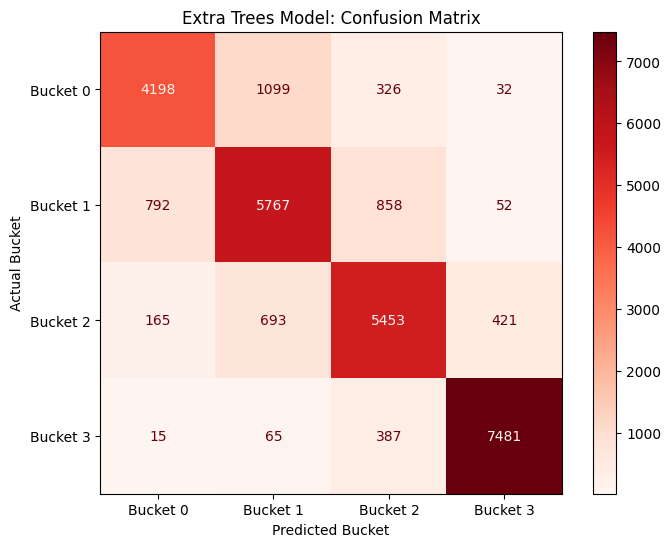

In [5]:
# make confusion matrix for extra trees model accuracy
# confusion matrix values are the following:
# [[4198 1099  326   32]
#  [ 792 5767  858   52]
#  [ 165  693 5453  421]
#  [  15   65  387 7481]]

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = np.array([
    [4198, 1099,  326,   32],
    [ 792, 5767,  858,   52],
    [ 165,  693, 5453,  421],
    [  15,   65,  387, 7481]
])

# total and correct predictions
total_predictions = np.sum(cm)
correct_predictions = np.trace(cm)

# accuracy
accuracy = correct_predictions / total_predictions
print(f"Overall Accuracy: {accuracy:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bucket 0', 'Bucket 1', 'Bucket 2', 'Bucket 3'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Reds, ax=ax, values_format='d')

plt.title("Extra Trees Model: Confusion Matrix")
plt.xlabel("Predicted Bucket")
plt.ylabel("Actual Bucket")
plt.show()

Overall Accuracy: 0.8236


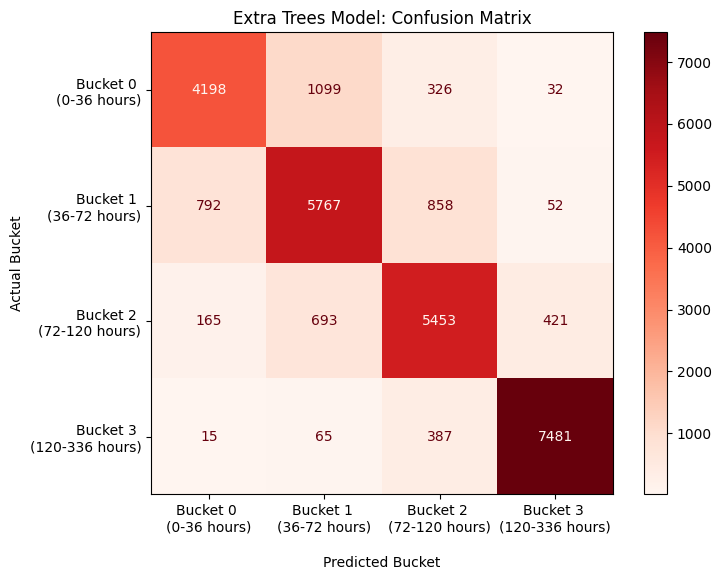

In [7]:
# make confusion matrix for extra trees model accuracy
# confusion matrix values are the following:
# [[4198 1099  326   32]
#  [ 792 5767  858   52]
#  [ 165  693 5453  421]
#  [  15   65  387 7481]]

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = np.array([
    [4198, 1099,  326,   32],
    [ 792, 5767,  858,   52],
    [ 165,  693, 5453,  421],
    [  15,   65,  387, 7481]
])

# total and correct predictions
total_predictions = np.sum(cm)
correct_predictions = np.trace(cm)

# accuracy
accuracy = correct_predictions / total_predictions
print(f"Overall Accuracy: {accuracy:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bucket 0 \n(0-36 hours)', 'Bucket 1 \n(36-72 hours)', 'Bucket 2 \n(72-120 hours)', 'Bucket 3 \n(120-336 hours)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Reds, ax=ax, values_format='d')

plt.title("Extra Trees Model: Confusion Matrix")
plt.xlabel("\nPredicted Bucket")
plt.ylabel("Actual Bucket")
plt.show()

Overall Accuracy: 82.3587%


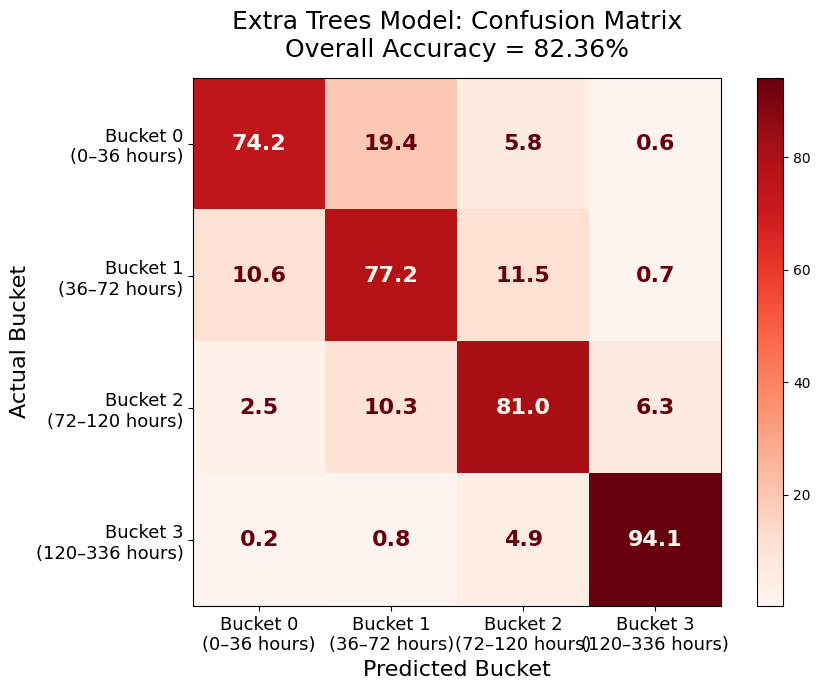

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix
cm = np.array([
    [4198, 1099,  326,   32],
    [ 792, 5767,  858,   52],
    [ 165,  693, 5453,  421],
    [  15,   65,  387, 7481]
])

# Overall accuracy
total_predictions = np.sum(cm)
correct_predictions = np.trace(cm)
accuracy = correct_predictions / total_predictions

print(f"Overall Accuracy: {accuracy:.4%}")

# Normalize each row to percentages
cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
# cm_pct_with_percent = cm_percent.astype()

labels = [
    'Bucket 0\n(0–36 hours)',
    'Bucket 1\n(36–72 hours)',
    'Bucket 2\n(72–120 hours)',
    'Bucket 3\n(120–336 hours)'
]

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_percent,
    display_labels=labels
)

disp.plot(
    cmap=plt.cm.Reds,
    ax=ax,
    values_format=".1f",
    colorbar=True
)

# Make numbers inside boxes larger
for text in disp.text_.ravel():
    text.set_fontsize(16)
    text.set_fontweight('bold')

# Increase axis label sizes
ax.set_xlabel("Predicted Bucket", fontsize=16)
ax.set_ylabel("Actual Bucket", fontsize=16)

# Increase tick label sizes
ax.tick_params(axis='both', labelsize=13)

# Larger title
plt.title(
    f"Extra Trees Model: Confusion Matrix\nOverall Accuracy = {accuracy:.2%}",
    fontsize=18,
    pad=15
)

plt.tight_layout()
plt.show()

Overall Accuracy: 82.36%


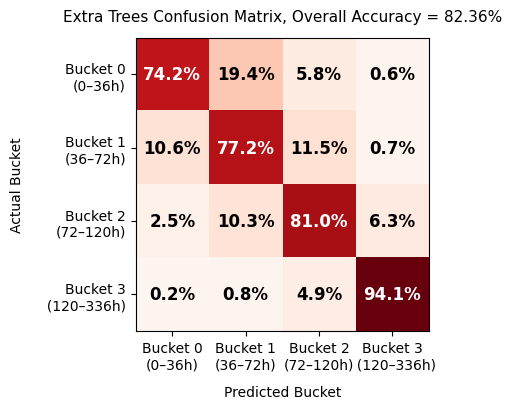

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix
cm = np.array([
    [4198, 1099,  326,   32],
    [ 792, 5767,  858,   52],
    [ 165,  693, 5453,  421],
    [  15,   65,  387, 7481]
])

# Accuracy
total_predictions = np.sum(cm)
correct_predictions = np.trace(cm)
accuracy = correct_predictions / total_predictions

print(f"Overall Accuracy: {accuracy:.2%}")

# Normalize rows to percentages
cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

labels = [
    'Bucket 0\n(0–36h)',
    'Bucket 1\n(36–72h)',
    'Bucket 2\n(72–120h)',
    'Bucket 3\n  (120–336h)'
]

# -----------------------------
# FIGURE (POSTER FRIENDLY)
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 4.2))  # wide + short

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_percent,
    display_labels=labels
)

disp.plot(
    cmap=plt.cm.Reds,
    ax=ax,
    values_format=".1f",
    colorbar=True
)

# -----------------------------
# CELL TEXT FORMATTING
# -----------------------------
for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        value = cm_percent[i, j]

        disp.text_[i, j].set_text(f"{value:.1f}%")
        disp.text_[i, j].set_fontsize(12)   # smaller for compact layout
        disp.text_[i, j].set_fontweight("bold")

        if value > 50:
            disp.text_[i, j].set_color("white")
        else:
            disp.text_[i, j].set_color("black")

# -----------------------------
# AXIS LABELS (smaller, cleaner)
# -----------------------------
ax.set_xlabel("Predicted Bucket", fontsize=10, labelpad=10)
ax.set_ylabel("Actual Bucket", fontsize=10, labelpad=10)

ax.tick_params(axis='both', labelsize=10)

cbar = disp.im_.colorbar
cbar.remove()

# TITLE (compact for poster)
# -----------------------------
plt.title(
    f"Extra Trees Confusion Matrix, Overall Accuracy = {accuracy:.2%}",
    fontsize=11,
    pad=12
)

plt.tight_layout()
# cbar.remove()
plt.show()

In [24]:
import numpy as np

cm = np.array([
    [4198, 1099,  326,   32],
    [ 792, 5767,  858,   52],
    [ 165,  693, 5453,  421],
    [  15,   65,  387, 7481]
])

tp = np.diag(cm)
support = cm.sum(axis=1)
predicted = cm.sum(axis=0)
recall = tp / support
precision = tp / predicted
f1 = 2 * (precision * recall) / (precision + recall)
macro_recall = np.mean(recall)
macro_precision = np.mean(precision)
macro_f1 = np.mean(f1)
for i in range(len(cm)):
    print(f"Class {i}:")
    print(f"  Recall   = {recall[i]:.4f}")
    print(f"  Precision= {precision[i]:.4f}")
    print(f"  F1-score = {f1[i]:.4f}\n")

print("----- Overall (Macro Avg) -----")
print(f"Macro Recall   = {macro_recall:.4f}")
print(f"Macro Precision= {macro_precision:.4f}")
print(f"Macro F1       = {macro_f1:.4f}")

Class 0:
  Recall   = 0.7424
  Precision= 0.8120
  F1-score = 0.7756

Class 1:
  Recall   = 0.7721
  Precision= 0.7564
  F1-score = 0.7642

Class 2:
  Recall   = 0.8100
  Precision= 0.7763
  F1-score = 0.7928

Class 3:
  Recall   = 0.9412
  Precision= 0.9368
  F1-score = 0.9390

----- Overall (Macro Avg) -----
Macro Recall   = 0.8164
Macro Precision= 0.8204
Macro F1       = 0.8179
